<a href="https://colab.research.google.com/github/nourswaid/ML-A_Z-/blob/main/Classification/naive_bayes/naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Naive Bayes

## Importing the libraries

In [1]:
import pandas as pd
import numpy as np

## Importing the dataset

In [2]:
df=pd.read_csv('/content/Social_Network_Ads.csv')
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

## Splitting the dataset into the Training set and Test set

In [3]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

## Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

## Training the Naive Bayes model on the Training set

In [5]:
from sklearn.naive_bayes import GaussianNB
classifier=GaussianNB()
classifier.fit(x_train,y_train)

GaussianNB()

## Predicting the Test set results

In [6]:
classifier.predict(sc.transform([[30,150000]]))

array([1])

In [7]:
prediction=classifier.predict(x_test)

## Making the Confusion Matrix

0.9125


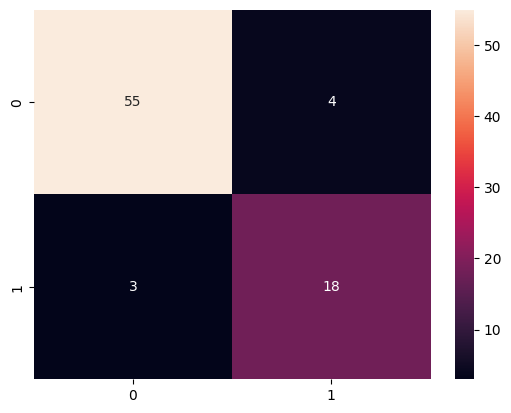

In [8]:
from sklearn.metrics import confusion_matrix,accuracy_score
import seaborn as sns

cm=confusion_matrix(prediction,y_test)
sns.heatmap(cm,annot=True)

print(accuracy_score(y_test,prediction))

## Visualising the Training set results

## Visualising the Test set results

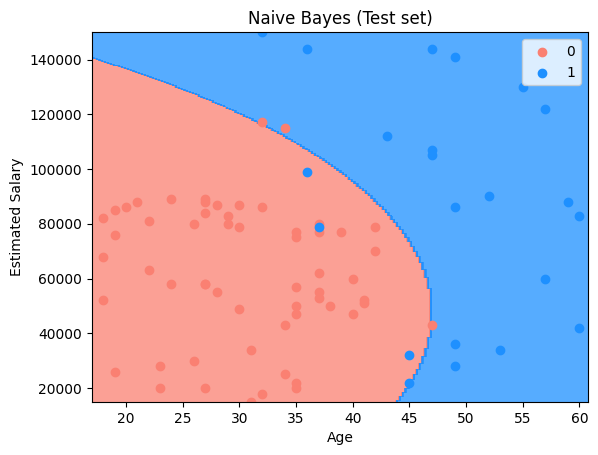

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(x_test), y_test
# Create a grid of points
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.25),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.25)
)
# Predict for each point on the grid
Z = classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape)
# Plot the decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap = ListedColormap(['#FA8072', '#1E90FF']) )
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
# Define colors for scatter plot
colors = ['#FA8072', '#1E90FF']
# Plot the test set points
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        color=colors[i], label=j
    )
# Add titles and labels
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()